In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from src.config import load_config
from src.runs.run_velocities import run
from src.features.value_surface import savitzky_golay, vxy
from src.data_io.load import load_match
from src.data_io.transform import build_normalised

pd.set_option("display.width", 160)
cfg = load_config(ROOT / "config.yaml")

In [2]:
res_vels = run(cfg=cfg)  # loops every match in matches_dir, one in RAM at a time

Match ID: 1874553 | Mean speed : 2.59 m/s | Minimum speed: 0.00 m/s | Maximum speed: 12.64 m/s | Counting: 469429 | Time: 14.0s
grid V range: 0.0 0.2795 | sampled cells: 266 / 294
kde V range: 0.0 0.2795 | sampled cells: 266 / 294
spline V range: 0.0 0.2795 | sampled cells: 266 / 294
Match ID: 1886347 | Mean speed : 2.64 m/s | Minimum speed: 0.00 m/s | Maximum speed: 11.59 m/s | Counting: 463314 | Time: 13.5s
grid V range: 0.0 0.2004 | sampled cells: 266 / 294
kde V range: 0.0 0.2004 | sampled cells: 266 / 294
spline V range: 0.0 0.2004 | sampled cells: 266 / 294
Match ID: 1899585 | Mean speed : 2.53 m/s | Minimum speed: 0.00 m/s | Maximum speed: 12.13 m/s | Counting: 407935 | Time: 13.5s
grid V range: 0.0 0.2284 | sampled cells: 270 / 294
kde V range: 0.0 0.2284 | sampled cells: 270 / 294
spline V range: 0.0 0.2284 | sampled cells: 270 / 294
Match ID: 1925299 | Mean speed : 2.46 m/s | Minimum speed: 0.00 m/s | Maximum speed: 12.81 m/s | Counting: 492741 | Time: 16.0s
grid V range: 0.0

In [3]:
# Fully separate feature: SG-smoothed velocities, gap-aware over detected-only runs.
# Needs one match's raw tracking (not the audit's concatenated alignment table).
vcfg = cfg["velocities"]
m0 = load_match(cfg["data"]["matches_dir"], 1874553)
_, tracking0 = build_normalised(m0)
sg = savitzky_golay(tracking0, fps=cfg["data"]["fps"])
sg[["vx", "vy", "speed"]].describe()


,vx,vy,speed
count,471512.000000,471512.000000,471512.000000
mean,-0.234866,0.017422,5.306016
std,14.216431,9.548922,16.284668
min,-394.693290,-295.174978,0.001667
25%,-0.810000,-1.256667,1.469970
50%,0.573333,0.030000,2.442252
75%,2.105000,1.296667,3.683631
max,433.750584,299.747532,511.935757


## Hypothesis: "speed peaks near the six-yard box"

Two passes:
1. **Naive** — bin every tracking frame by distance to the goal line. Averages
   over *all* frames there, which mixes in standing goalkeepers and marking
   defenders — expect this to be flat or even lower near the box.
2. **Conditioned on `off_ball_run` events** — the hypothesis is really about
   purposeful attacking sprints, not standing around. Compare the peak tracked
   speed during runs that end inside the six-yard box vs. runs that don't.


In [4]:
import numpy as np

# Pass 1 (naive): all frames, attacking outfield players only (in_possession
# excludes GKs / off-ball defenders who stand still near their own box).
t = tracking0.merge(sg[["frame", "player_id", "speed"]], on=["frame", "player_id"]).dropna(subset=["speed"])
att = t[t.in_possession & ~t.is_gk].copy()
att["dist_to_goal"] = m0.pitch_length / 2 - att.x.abs()  # 0 = goal line, 5.5 = edge of six-yard box

bins = np.arange(0, m0.pitch_length / 2 + 5, 5)
att["dist_bin"] = pd.cut(att.dist_to_goal, bins)
naive = att.groupby("dist_bin", observed=True).speed.agg(mean="mean", p95=lambda s: s.quantile(0.95),
                                                         max="max", n="count")
naive


,mean,p95,max,n
dist_bin,,,,
"(0.0, 5.0]",11.414013,65.654285,458.283148,2245
"(5.0, 10.0]",10.308060,66.816763,422.461578,7468
"(10.0, 15.0]",7.367563,7.467328,360.891775,12055
"(15.0, 20.0]",6.024536,6.912678,358.887736,18518
"(20.0, 25.0]",5.872968,7.171707,293.452640,21522
"(25.0, 30.0]",4.897627,6.838235,292.153833,24438
"(30.0, 35.0]",4.942860,6.743730,351.403265,26483
"(35.0, 40.0]",4.649266,6.699944,274.768503,30287
"(40.0, 45.0]",4.248200,6.433401,202.738585,32598


In [5]:
# Pass 2: condition on off_ball_run events. player_id on an off_ball_run row is
# the runner; x_end/y_end is where the run finishes. "speed_avg" is SkillCorner's
# own per-run average (km/h, from its own kinematics) - kept here only as a
# cross-check against our independently-computed peak tracked speed (m/s), not
# because the two are on the same scale.
from src.data_io.load import list_match_ids


def ends_in_six_yard_box(x_end, y_end, pitch_length=105.0):
    return (x_end.abs() >= pitch_length / 2 - 5.5) & (x_end.abs() <= pitch_length / 2) & (y_end.abs() <= 9.16)


match_ids = list_match_ids(cfg["data"]["matches_dir"])[:3]  # widen once this looks promising
runs = []
for mid in match_ids:
    m = load_match(cfg["data"]["matches_dir"], mid)
    _, tracking_m = build_normalised(m)
    sg_m = savitzky_golay(tracking_m, fps=cfg["data"]["fps"], window_length=vcfg["window_length"],
                          polyorder=vcfg["polyorder"], max_speed_mps=vcfg["max_speed_mps"])

    obr = m.events[m.events.event_type == "off_ball_run"].dropna(subset=["x_end", "y_end", "player_id"]).copy()
    obr["ends_in_six_yard_box"] = ends_in_six_yard_box(obr.x_end, obr.y_end, m.pitch_length)
    obr["peak_speed_tracked"] = [
        sg_m.loc[(sg_m.player_id == r.player_id) & sg_m.frame.between(r.frame_start, r.frame_end), "speed"].max()
        for r in obr.itertuples()
    ]
    obr["match_id"] = mid
    runs.append(obr[["match_id", "event_id", "player_id", "ends_in_six_yard_box", "speed_avg", "peak_speed_tracked"]])

runs = pd.concat(runs, ignore_index=True)
by_box = runs.groupby("ends_in_six_yard_box")[["speed_avg", "peak_speed_tracked"]].agg(["mean", "count"])
by_box


speed_avg       peak_speed_tracked      
                           mean count               mean count
ends_in_six_yard_box                                          
False                 18.510000  1555           5.661437  1577
True                  22.053333    12           7.068853    12

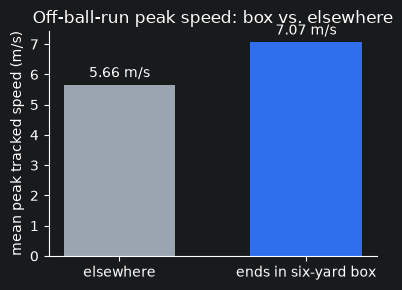

In [6]:
import matplotlib.pyplot as plt

means = runs.groupby("ends_in_six_yard_box").peak_speed_tracked.mean()
labels = ["elsewhere", "ends in six-yard box"]
colors = ["#9aa5b1", "#2f6fed"]  # muted gray vs. one accent hue — identity by position, not a cycled palette

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(labels, means.reindex([False, True]).to_numpy(), color=colors, width=0.6)
ax.bar_label(bars, fmt="%.2f m/s", padding=3)
ax.set_ylabel("mean peak tracked speed (m/s)")
ax.set_title("Off-ball-run peak speed: box vs. elsewhere")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
